Aim

To study and implement deep learning models using TensorFlow and Keras frameworks.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


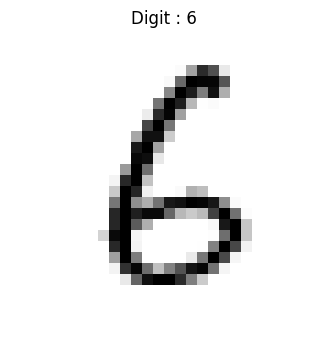

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8548 - loss: 0.5089 - val_accuracy: 0.9453 - val_loss: 0.2021
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9379 - loss: 0.2134 - val_accuracy: 0.9577 - val_loss: 0.1463
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9538 - loss: 0.1588 - val_accuracy: 0.9659 - val_loss: 0.1218
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9630 - loss: 0.1262 - val_accuracy: 0.9681 - val_loss: 0.1098
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9695 - loss: 0.1048 - val_accuracy: 0.9709 - val_loss: 0.1015
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9739 - loss: 0.0894 - val_accuracy: 0.9724 - val_loss: 0.0970
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9771 - loss: 0.0775 - val_accuracy: 0.9721 - val_loss: 0.0929
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9809 - loss: 0.0669 - val_accuracy: 0.

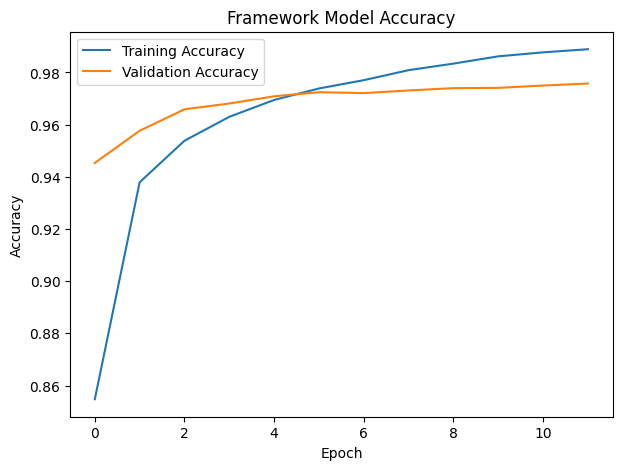

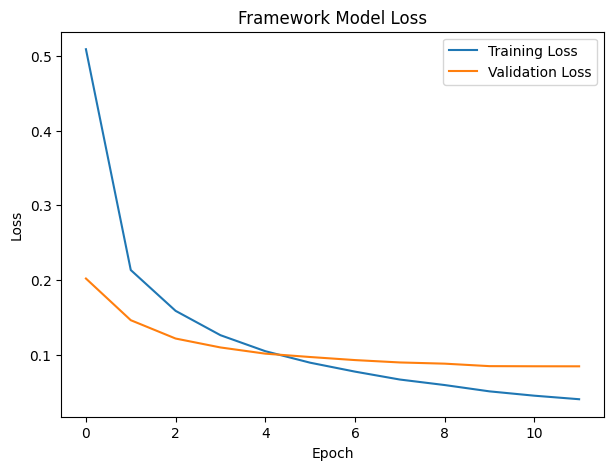

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step

Predicted Digit : 1


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

# Load Handwritten Digit Dataset
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# Show Random Image
random_index = np.random.randint(0, 1000)

plt.figure(figsize=(4,4))

plt.imshow(
    train_data[random_index],
    cmap='binary'
)

plt.title(
    f"Digit : {train_labels[random_index]}"
)

plt.axis("off")
plt.show()

# Normalize Pixel Values
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Flatten Dataset
train_data = train_data.reshape(
    train_data.shape[0],
    28 * 28
)

test_data = test_data.reshape(
    test_data.shape[0],
    28 * 28
)

# Convert Labels to Categorical
train_labels = to_categorical(
    train_labels
)

test_labels = to_categorical(
    test_labels
)

# Create Deep Learning Model
digit_classifier = Sequential()

# Hidden Layer 1
digit_classifier.add(Dense(
    256,
    activation='relu',
    input_dim=784
))

digit_classifier.add(BatchNormalization())

# Hidden Layer 2
digit_classifier.add(Dense(
    128,
    activation='relu'
))

digit_classifier.add(BatchNormalization())

# Hidden Layer 3
digit_classifier.add(Dense(
    64,
    activation='relu'
))

# Output Layer
digit_classifier.add(Dense(
    10,
    activation='softmax'
))

# Display Model Summary
digit_classifier.summary()

# Compile Neural Network
digit_classifier.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
model_history = digit_classifier.fit(
    train_data,
    train_labels,
    epochs=12,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# Evaluate Accuracy
network_loss, network_accuracy = digit_classifier.evaluate(
    test_data,
    test_labels,
    verbose=0
)

print("\nNeural Network Loss :", network_loss)
print("Neural Network Accuracy :", network_accuracy)

# Accuracy Plot
plt.figure(figsize=(7,5))

plt.plot(
    model_history.history['accuracy']
)

plt.plot(
    model_history.history['val_accuracy']
)

plt.title("Framework Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

# Loss Plot
plt.figure(figsize=(7,5))

plt.plot(
    model_history.history['loss']
)

plt.plot(
    model_history.history['val_loss']
)

plt.title("Framework Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

# Predict Digit
sample_prediction = digit_classifier.predict(
    test_data[5:6]
)

predicted_digit = np.argmax(sample_prediction)

print("\nPredicted Digit :", predicted_digit)

Conclusion

Successfully implemented deep learning models using TensorFlow and Keras frameworks on the MNIST handwritten digit dataset.